# Project 02 - Business Analytics: EDA & Storytelling with Olist

This notebook explores the *Brazilian E-Commerce Public Dataset by Olist* (Kaggle) to
understand the operational and commercial drivers behind order satisfaction and revenue
on a real Brazilian e-commerce marketplace.

We will:
- frame the analysis from a **business stakeholder perspective** (Head of Operations) and
  state hypotheses upfront, before looking at the data,
- perform **data understanding and quality checks** across multiple relational tables,
- run a thorough **exploratory data analysis (EDA)**: sales/revenue trends, delivery
  performance, review scores and geographic patterns,
- formally **validate (or refute) each hypothesis** with the appropriate statistical test,
- and conclude with **business storytelling**: findings, implications and recommended actions.

**Business question**

> Where are orders concentrated geographically, how does delivery performance affect
> customer satisfaction, and which product categories and payment patterns drive revenue,
> with what statistical confidence?

**Dataset**
- Each row (after joining): one delivered order, enriched with customer, payment, item and
  review information.
- Key variables: `order_purchase_timestamp`, `delivery_delay_days`, `review_score`,
  `total_payment`, `max_installments`, `customer_state`, `product_category_name_english`.
- Coverage: ~100k orders placed between 2016 and 2018.
- Source: [Kaggle - Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

> **Note (Portugues):** Este projeto foi desenvolvido como parte do meu portfolio de Data
> Science, com foco em analise exploratoria de dados e storytelling de negocio aplicados a
> um marketplace de e-commerce brasileiro.

## Notebook Roadmap

1. Business context, hypotheses & data loading
2. Data understanding & quality
3. Exploratory data analysis (EDA)
4. Hypothesis validation with statistical tests
5. Key insights & business storytelling
6. Conclusions and next steps

## 1. Business Context, Hypotheses & Data Loading

**Olist** is a Brazilian e-commerce marketplace connector that links small merchants to
major retail platforms. The dataset covers ~100k orders placed between 2016 and 2018, with
information on payments, delivery, reviews, products, and geolocation.

**Stakeholder perspective:** imagine you are a **Head of Operations** at Olist. Your key
questions:

- Where are orders concentrated geographically, and is that aligned with purchasing power?
- How is delivery performance affecting customer satisfaction?
- Which product categories drive revenue - and which have the worst review scores?
- Are there seasonal patterns that should drive planning?

> This framing comes directly from *Data Science for Business* (Provost & Fawcett): the
> analyst must connect every chart and test back to a decision someone needs to make.

### Hypotheses

Before looking at the data, we formulate the following hypotheses. Each will be validated
or refuted in Section 4.

| # | Hypothesis | Expected direction | Test |
|---|---|---|---|
| H1 | Orders delivered **late** receive significantly **lower review scores** than on-time orders | Negative | One-tailed t-test (mean review: late vs. on-time) |
| H2 | The **Southeast region** (SP, RJ, MG, ES) accounts for the majority of revenue | >50% share | Descriptive (proportion) |
| H3 | Higher **payment installments** are associated with higher **order value** | Positive | Pearson r + scatter |
| H4 | Review scores differ significantly **across product categories** | Groups not equal | One-way ANOVA |

> Stating hypotheses before EDA is a scientific thinking habit that differentiates a data
> analyst from a data reporter.

### How to reproduce - Data access

This notebook downloads the dataset automatically via the **Kaggle API**.

To run it locally:

1. Create a free account at [kaggle.com](https://www.kaggle.com).
2. Go to **Settings -> API -> Create New Token** to download your `kaggle.json`.
3. Place the file at the standard path:
   - Windows: `C:\Users\<YOUR_USER>\.kaggle\kaggle.json`
   - Mac/Linux: `~/.kaggle/kaggle.json`
4. Install dependencies: `pip install -r requirements.txt`
5. Run the notebook - the dataset will be downloaded automatically.

No credentials are stored in this repository.

In [2]:
# === Standard Library ===
import warnings
warnings.filterwarnings('ignore')
import os
import subprocess
import sys

# === Data Manipulation ===
import pandas as pd
import numpy as np

# === Statistical Tests ===
from scipy import stats
from scipy.stats import ttest_ind, skew

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Display settings ===
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

print('Libraries loaded.')

Libraries loaded.


In [3]:
# Download dataset via Kaggle API

DATASET = "olistbr/brazilian-ecommerce"
DATA_DIR = "../data"

if not os.path.exists(f"{DATA_DIR}/olist_orders_dataset.csv"):
    os.makedirs(DATA_DIR, exist_ok=True)
    subprocess.run(
        [
            sys.executable,
            "-m",
            "kaggle",
            "datasets",
            "download",
            "-d",
            DATASET,
            "--unzip",
            "-p",
            DATA_DIR,
        ],
        check=True,
    )

# Load all tables
orders        = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv")
order_items   = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")
payments      = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
reviews       = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv")
customers     = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
products      = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
product_names = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")
sellers       = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
geolocation   = pd.read_csv(f"{DATA_DIR}/olist_geolocation_dataset.csv")

print('Datasets loaded:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('payments', payments), ('reviews', reviews),
                 ('customers', customers), ('products', products)]:
    print(f'  {name}: {df.shape[0]:,} rows x {df.shape[1]} cols')

Datasets loaded:
  orders: 99,441 rows x 8 cols
  order_items: 112,650 rows x 7 cols
  payments: 103,886 rows x 5 cols
  reviews: 99,224 rows x 7 cols
  customers: 99,441 rows x 5 cols
  products: 32,951 rows x 9 cols


## 2. Data Understanding & Quality

In this section we characterise the relational structure of the Olist schema, check data
quality across the core tables, engineer the delivery-delay feature, and build the master
analytical dataset used throughout the rest of the notebook.

Concepts applied:
- Relational schema understanding (fact/dimension tables)
- Missing-value diagnostics
- Datetime parsing and feature engineering (delivery delay)
- Table joins and aggregation (group-by) for a master analytical view

### 2.1 Schema overview

In [4]:
# Schema overview
# The Olist schema is a star-like model:
#   orders (fact) -> order_items, payments, reviews, customers
#   order_items -> products, sellers

orders.info()
orders.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


### 2.1 Results - Schema overview

The Olist schema follows a star-like model: `orders` is the fact table, joined to
`order_items`, `payments`, `reviews` and `customers`, with `order_items` further linked to
`products` and `sellers`. `orders` carries the order lifecycle timestamps (purchase,
approval, carrier handoff, customer delivery, estimated delivery) needed for the delivery
delay feature engineered next.

### 2.2 Missing values

In [5]:
# Missing values
def missing_summary(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'missing': missing, 'pct': pct})
    return result[result.missing > 0].sort_values('pct', ascending=False)

for name, df in [('orders', orders), ('reviews', reviews), ('products', products)]:
    print(f'\n-- {name} --')
    print(missing_summary(df, name))


-- orders --
                               missing    pct
order_delivered_customer_date     2965 2.9800
order_delivered_carrier_date      1783 1.7900
order_approved_at                  160 0.1600

-- reviews --
                        missing     pct
review_comment_title      87656 88.3400
review_comment_message    58247 58.7000

-- products --
                            missing    pct
product_category_name           610 1.8500
product_name_lenght             610 1.8500
product_description_lenght      610 1.8500
product_photos_qty              610 1.8500
product_weight_g                  2 0.0100
product_length_cm                 2 0.0100
product_height_cm                 2 0.0100
product_width_cm                  2 0.0100


### 2.2 Results - Missing values

Missingness is concentrated in `orders` (delivery timestamps for orders that are not yet
delivered/canceled) and in `reviews`/`products` free-text fields. Core numerical and
categorical fields used in this analysis (`order_status`, `review_score`,
`product_category_name`) have low missingness, so listwise deletion at the point of use
(rather than imputation) is an adequate strategy for this EDA.

### 2.3 Datetime parsing & delivery delay feature

In [6]:
# Parse datetime columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Delivery delay feature
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

orders['is_late'] = orders['delivery_delay_days'] > 0

print('Date columns parsed. Delay feature created.')
orders[['order_id', 'delivery_delay_days', 'is_late']].head(5)

Date columns parsed. Delay feature created.


,order_id,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0000,False
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0000,False
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0000,False
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0000,False
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0000,False


### 2.3 Results - Delivery delay feature

All order lifecycle timestamps are parsed to `datetime`. `delivery_delay_days` is defined
as the gap (in days) between the actual customer delivery date and the estimated delivery
date promised at purchase time; positive values indicate a late delivery. The boolean flag
`is_late` derived from this feature is the basis for hypothesis H1 in Section 4.

### 2.4 Master join (orders + payments + items + reviews)

In [7]:
# Master join
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0])
).reset_index()

items_agg = order_items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    total_item_value=('price', 'sum')
).reset_index()

reviews_clean = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')

df = (
    orders
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='left')
)

df_delivered = df[df['order_status'] == 'delivered'].copy()

print(f'Master DataFrame: {df.shape}')
print(f'Delivered orders: {df_delivered.shape}')

Master DataFrame: (99441, 18)
Delivered orders: (96478, 18)


### 2.4 Results - Master analytical dataset

Payments are aggregated to order level (total payment value, max installments, dominant
payment type) and order items are aggregated to order level (item count, total item value).
Reviews are de-duplicated to the most recent review per order. The resulting `df` is
filtered to `order_status == "delivered"` (`df_delivered`), which is the population used
for all EDA and hypothesis tests below, since delivery performance and review scores are
only meaningful for completed orders.

## 3. Exploratory Data Analysis (EDA)

In this section we examine sales and revenue trends, delivery performance, review score
distributions and geographic patterns. The findings here directly motivate and contextualize
the formal hypothesis tests in Section 4.

Concepts applied:
- Time-series aggregation (monthly orders and revenue)
- Distribution shape and skewness for monetary variables
- Group comparisons (delivery status, geography) via descriptive statistics and plots

### 3.1 Monthly order volume & revenue trend

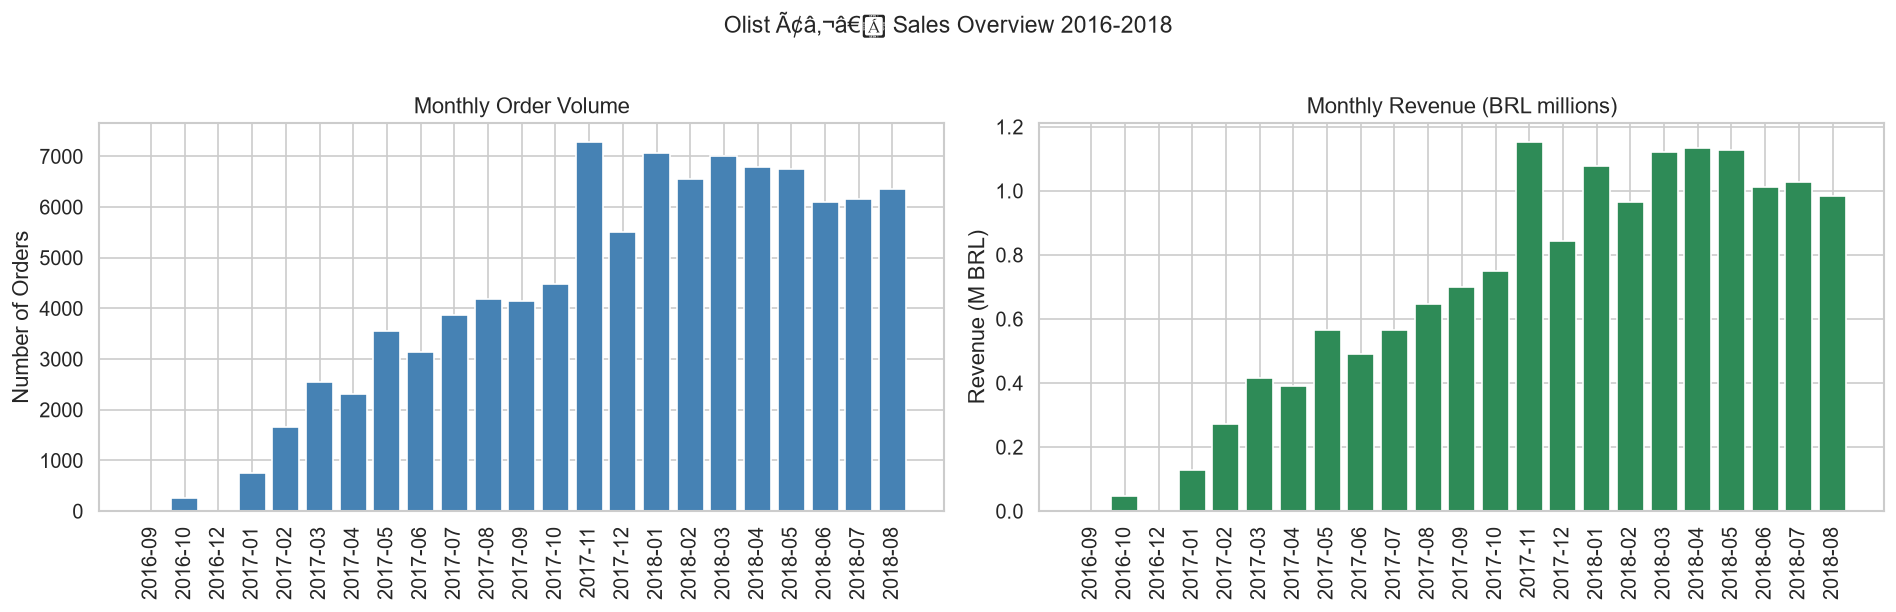

Total orders:       96,478
Total revenue:      BRL 15,422,462
Avg order value:    BRL 159.86
Median order value: BRL 105.28


In [8]:
df_delivered['year_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly = df_delivered.groupby('year_month').agg(
    orders_count=('order_id', 'count'),
    revenue=('total_payment', 'sum')
).reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(monthly['year_month'], monthly['orders_count'], color='steelblue')
axes[0].set_title('Monthly Order Volume')
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_ylabel('Number of Orders')

axes[1].bar(monthly['year_month'], monthly['revenue'] / 1e6, color='seagreen')
axes[1].set_title('Monthly Revenue (BRL millions)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylabel('Revenue (M BRL)')

plt.suptitle('Olist ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â Sales Overview 2016-2018', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total orders:       {len(df_delivered):,}')
print(f'Total revenue:      BRL {df_delivered["total_payment"].sum():,.0f}')
print(f'Avg order value:    BRL {df_delivered["total_payment"].mean():.2f}')
print(f'Median order value: BRL {df_delivered["total_payment"].median():.2f}')

### 3.1 Results - Sales & revenue overview

- **Total orders:** 96,478 delivered orders | **Total revenue:** BRL 15,422,462.
- **Avg order value:** BRL 159.86 vs. **median:** BRL 105.28 - the mean sits well above the
  median, an early signal of the right-skewed order-value distribution confirmed in 3.2.
- **Trend:** order volume is near zero from Sep-Dec 2016 (marketplace ramp-up), grows
  steadily through 2017, and **spikes sharply in November 2017** (~7,250 orders, ~BRL 1.15M
  revenue) - consistent with a Black Friday effect. Volume then plateaus at roughly
  6,000-7,000 orders/month through mid-2018.
- Orders and revenue move together month-to-month, with no sign of revenue growing faster
  or slower than volume (i.e., no strong average-ticket trend over time).

### 3.2 Order value distribution

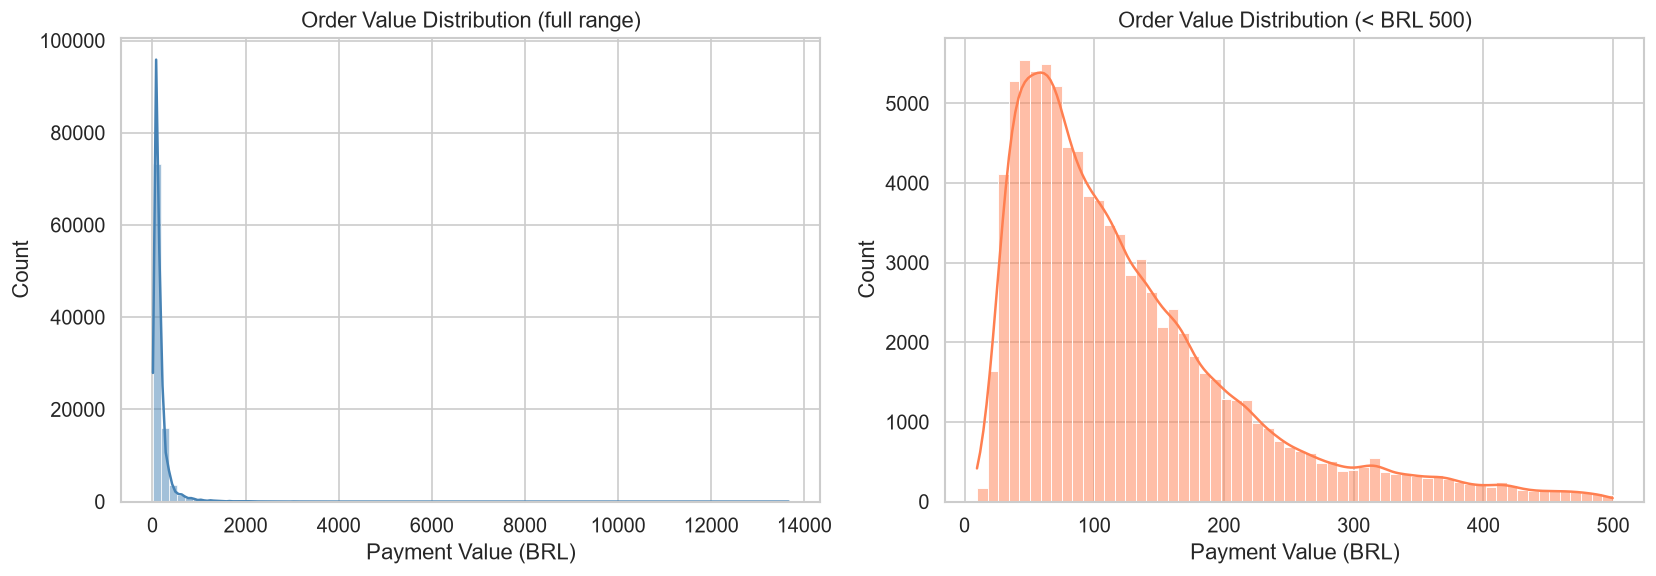

Skewness: 9.37
Heavy right tail: a small portion of high-value orders inflates the mean.


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_delivered['total_payment'], bins=80, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Order Value Distribution (full range)')
axes[0].set_xlabel('Payment Value (BRL)')

sns.histplot(
    df_delivered[df_delivered['total_payment'] < 500]['total_payment'],
    bins=60, kde=True, ax=axes[1], color='coral'
)
axes[1].set_title('Order Value Distribution (< BRL 500)')
axes[1].set_xlabel('Payment Value (BRL)')

plt.tight_layout()
plt.show()

print(f'Skewness: {skew(df_delivered["total_payment"].dropna()):.2f}')
print('Heavy right tail: a small portion of high-value orders inflates the mean.')

### 3.2 Results - Order value distribution

- **Skewness = 9.37** - an extremely heavy right tail, far beyond typical "highly skewed"
  thresholds (skew > 1).
- The bulk of orders cluster well under BRL 500, with the distribution peaking around
  BRL 50-100 and decaying gradually; a small number of high-value outliers (up to roughly
  BRL 13,000+) pull the mean (159.86) well above the median (105.28).
- **Implication:** any downstream modelling of order value (e.g. Project 03) should
  consider a log transform or outlier capping, mirroring the Box-Cox treatment applied to
  `charges` in Project 01.

### 3.3 Delivery performance

Late delivery rate: 6.8%


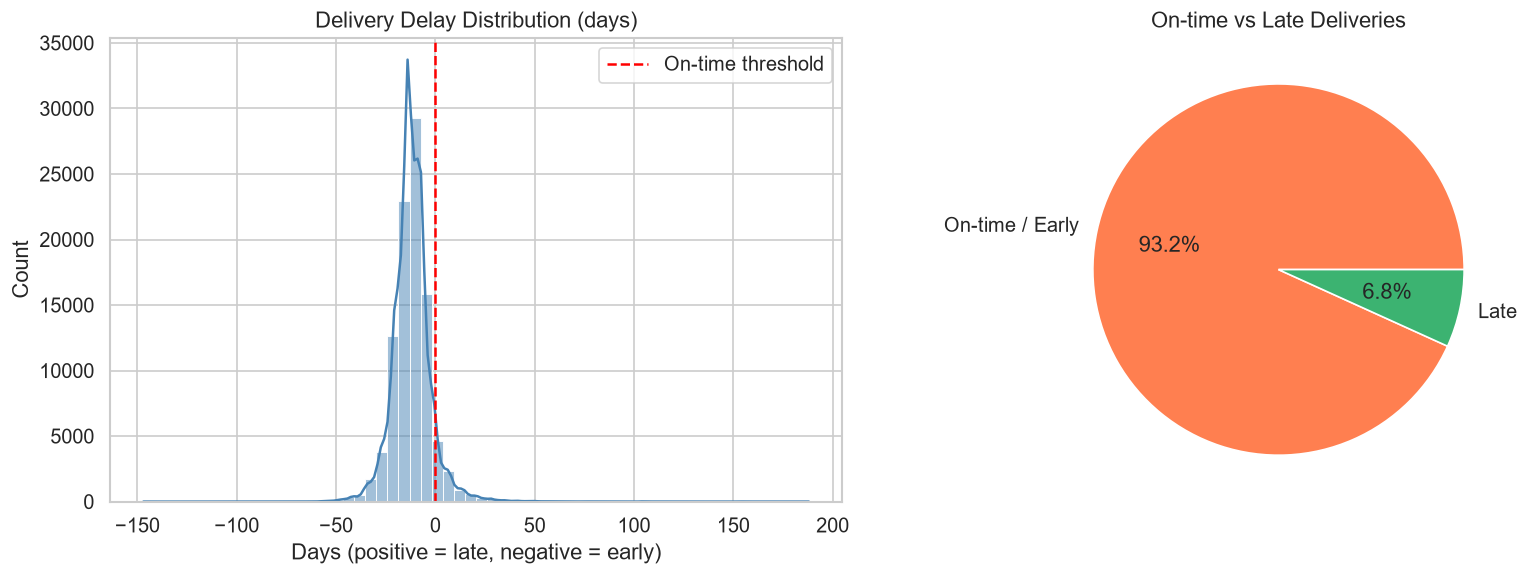

In [10]:
delay_df = df_delivered.dropna(subset=['delivery_delay_days'])

late_pct = delay_df['is_late'].mean() * 100
print(f'Late delivery rate: {late_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(delay_df['delivery_delay_days'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', label='On-time threshold')
axes[0].set_title('Delivery Delay Distribution (days)')
axes[0].set_xlabel('Days (positive = late, negative = early)')
axes[0].legend()

delay_df = delay_df.copy()
delay_df['delivery_status'] = delay_df['is_late'].map({True: 'Late', False: 'On-time / Early'})
status_counts = delay_df['delivery_status'].value_counts()
axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=['coral', 'mediumseagreen'])
axes[1].set_title('On-time vs Late Deliveries')

plt.tight_layout()
plt.show()

### 3.3 Results - Delivery performance

- **Late delivery rate: 6.8%** (93.2% on-time/early).
- The delay distribution is tightly concentrated around **-10 days**, meaning most orders
  arrive about 10 days **earlier** than the estimated delivery date promised at purchase -
  Olist's delivery estimates appear conservative by design.
- A long right tail extends out to roughly **190 days late** for a small number of extreme
  outliers, with a smaller left tail reaching about -150 days (unusually early deliveries).

### 3.4 Customer review scores

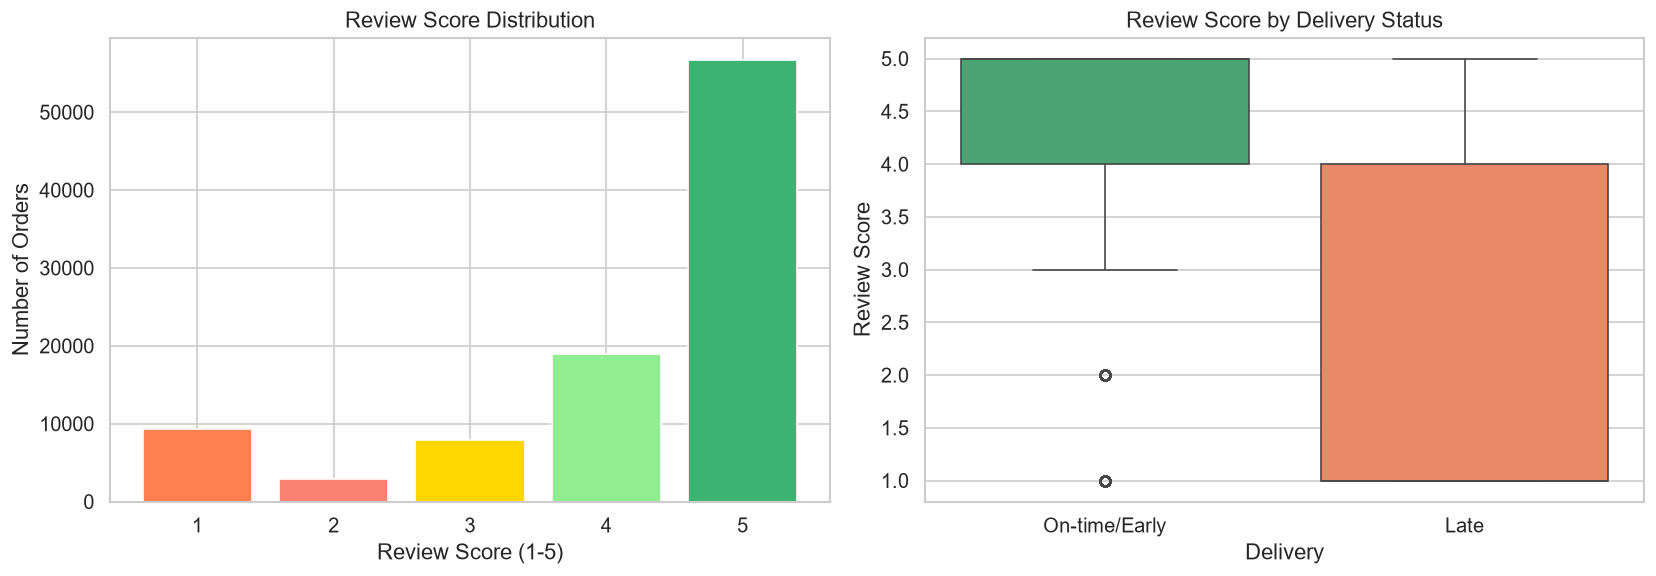

Mean score (on-time): 4.29
Mean score (late):    2.27


In [11]:
review_counts = df_delivered['review_score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(review_counts.index, review_counts.values,
            color=['coral', 'salmon', 'gold', 'lightgreen', 'mediumseagreen'])
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Review Score (1-5)')
axes[0].set_ylabel('Number of Orders')

plot_df = df_delivered.dropna(subset=['review_score', 'is_late']).copy()
plot_df['Delivery'] = plot_df['is_late'].map({True: 'Late', False: 'On-time/Early'})
sns.boxplot(data=plot_df, x='Delivery', y='review_score', ax=axes[1],
            palette={'Late': 'coral', 'On-time/Early': 'mediumseagreen'})
axes[1].set_title('Review Score by Delivery Status')
axes[1].set_ylabel('Review Score')

plt.tight_layout()
plt.show()

print(f'Mean score (on-time): {plot_df[plot_df["is_late"]==False]["review_score"].mean():.2f}')
print(f'Mean score (late):    {plot_df[plot_df["is_late"]==True]["review_score"].mean():.2f}')

### 3.4 Results - Customer review scores

- The review-score distribution is strongly skewed toward **5** (~57k orders, ~59% of
  reviews), with a **secondary spike at 1** (~9k, ~10%) - a classic J-shaped pattern typical
  of e-commerce reviews, where extreme experiences (very good or very bad) are most likely
  to generate a review.
- **Mean score, on-time/early: 4.29** vs. **late: 2.27** - a stark gap already visible in
  the boxplot: the on-time group's interquartile range sits at 4-5, while the late group's
  drops to 1-4. This is a strong preview of the formal H1 test in Section 4.1.

### 3.5 Geographic patterns

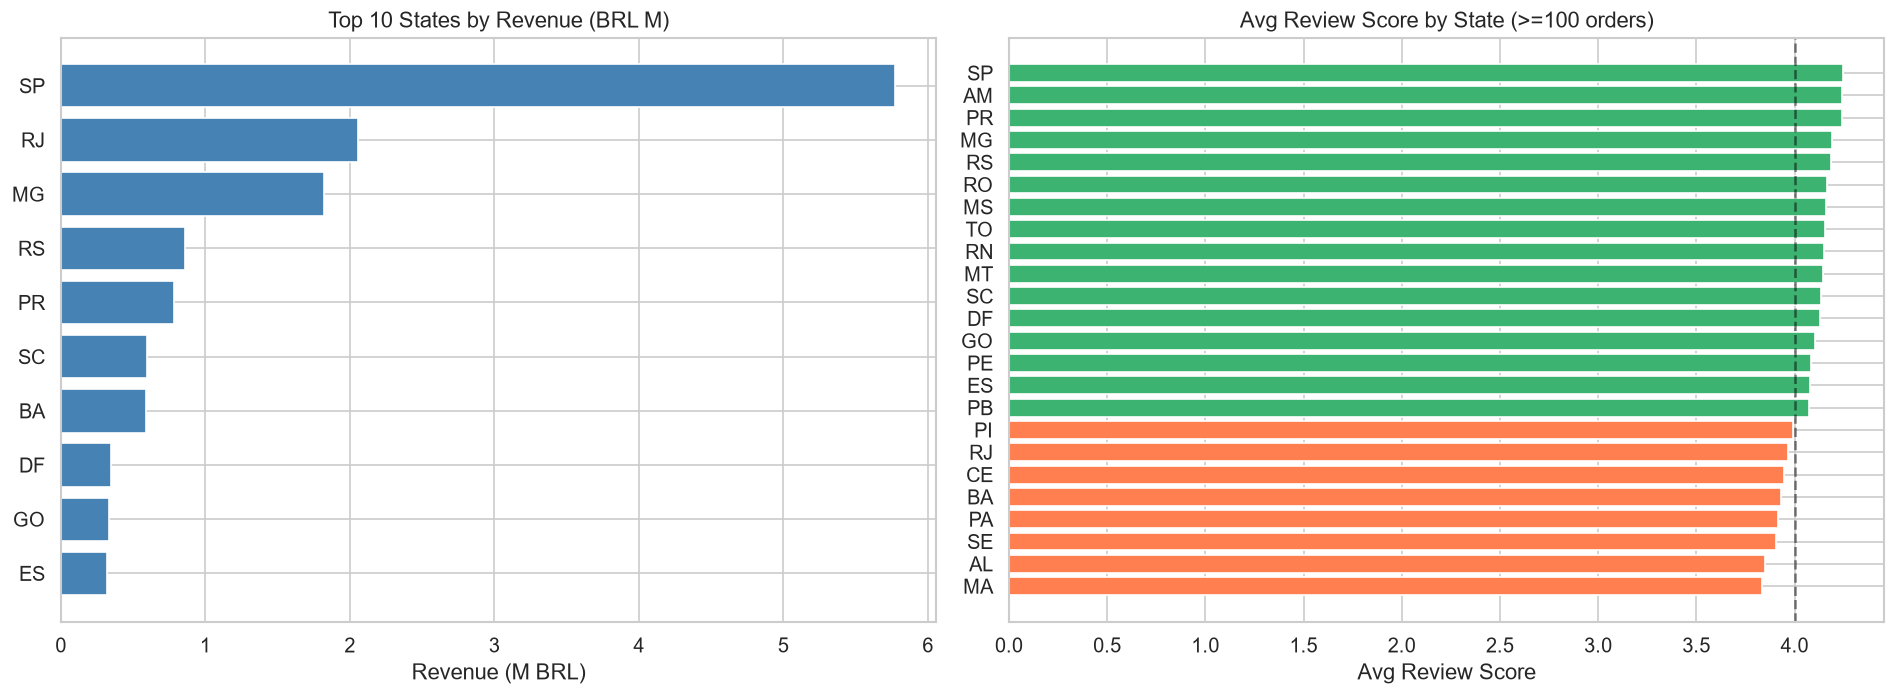

Southeast region revenue share: 64.6%


In [12]:
by_state = df_delivered.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    revenue=('total_payment', 'sum'),
    avg_review=('review_score', 'mean')
).sort_values('revenue', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = by_state.head(10)
axes[0].barh(top10['customer_state'][::-1], top10['revenue'][::-1] / 1e6, color='steelblue')
axes[0].set_title('Top 10 States by Revenue (BRL M)')
axes[0].set_xlabel('Revenue (M BRL)')

top_states = by_state[by_state['orders'] > 100].sort_values('avg_review')
colors = ['coral' if s < 4.0 else 'mediumseagreen' for s in top_states['avg_review']]
axes[1].barh(top_states['customer_state'], top_states['avg_review'], color=colors)
axes[1].axvline(4.0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Avg Review Score by State (>=100 orders)')
axes[1].set_xlabel('Avg Review Score')

plt.tight_layout()
plt.show()

southeast = ['SP', 'RJ', 'MG', 'ES']
se_pct = by_state[by_state['customer_state'].isin(southeast)]['revenue'].sum() / by_state['revenue'].sum() * 100
print(f'Southeast region revenue share: {se_pct:.1f}%')

### 3.5 Results - Geographic patterns (H2)

- **Top revenue states:** SP dominates by a wide margin (~BRL 5.8M), followed by RJ
  (~BRL 2.0M) and MG (~BRL 1.8M), then a second tier (RS, PR, SC, BA, DF, GO, ES) each well
  under BRL 1M.
- **Southeast region revenue share: 64.6%** - clearly confirms **H2** (>50% threshold).
- **Avg review score by state (>=100 orders):** states such as SP, AM, PR, MG and RS sit
  above the 4.0 reference line, while MA, AL, SE, PA, BA, CE, RJ and PI sit below it.
  Notably, **RJ** - the #2 state by revenue - is among the below-4.0 group, an interesting
  tension between revenue concentration and customer satisfaction worth flagging to
  operations.

### 3.6 EDA summary

| Finding | Implication for hypothesis testing |
|---------|-------------------------------------|
| Order value is extremely right-skewed (skew = 9.37) | Use median alongside mean; H3 already caps the top 1% of `total_payment` before testing |
| Review scores concentrate at the extremes (5 and 1) | The mean-based t-test in H1 is well justified by the large sample size (n > 6k in both groups), per CLT |
| On-time vs. late mean review scores diverge sharply in the EDA preview (4.29 vs. 2.27) | Motivates the formal one-tailed t-test for H1 in Section 4.1 |
| Southeast region holds 64.6% of revenue, but RJ (its #2 state) scores below the 4.0 review threshold | Directly confirms H2; revenue concentration does not guarantee satisfaction concentration |

**Next step:** Section 4 formally tests H1, H3 and H4 with the appropriate statistical
tests, building on the patterns observed here.

## 4. Hypothesis Validation with Statistical Tests

Each test follows the same structure: state H0/H1 -> run test -> interpret p-value ->
business conclusion. H2 (Southeast revenue share) is purely descriptive and was already
addressed in Section 3.5, so it is not repeated here.

### 4.1 H1 - Late delivery vs. review score (one-tailed t-test)

In [13]:
# H1: Late deliveries -> lower review scores
# H0: mean review score equal between late and on-time
# H1: mean review score lower for late orders (one-tailed)

alpha = 0.05

test_df = df_delivered.dropna(subset=['review_score', 'is_late'])
late_scores   = test_df[test_df['is_late'] == True]['review_score']
ontime_scores = test_df[test_df['is_late'] == False]['review_score']

t_stat, p_val = stats.ttest_ind(late_scores, ontime_scores, alternative='less')

print('H1: Late deliveries lower review scores')
print(f'  On-time mean: {ontime_scores.mean():.3f}  (n={len(ontime_scores):,})')
print(f'  Late mean:    {late_scores.mean():.3f}  (n={len(late_scores):,})')
print(f'  t-statistic:  {t_stat:.4f}')
print(f'  p-value:      {p_val:.4e}')
print(f'  Result: {"REJECT H0" if p_val < alpha else "FAIL TO REJECT H0"} (alpha={alpha})')

pooled_std = np.sqrt((late_scores.std()**2 + ontime_scores.std()**2) / 2)
cohens_d = (ontime_scores.mean() - late_scores.mean()) / pooled_std
print(f"  Cohen's d: {cohens_d:.3f} (effect size)")

H1: Late deliveries lower review scores
  On-time mean: 4.290  (n=89,451)
  Late mean:    2.271  (n=6,381)
  t-statistic:  -131.8486
  p-value:      0.0000e+00
  Result: REJECT H0 (alpha=0.05)
  Cohen's d: 1.467 (effect size)


### 4.1 Results - H1 (late delivery vs. review score)

- **On-time mean: 4.290** (n = 89,451) vs. **late mean: 2.271** (n = 6,381).
- **t-statistic = -131.85**, **p-value â‰ˆ 0** (effectively zero in floating-point terms).
- **REJECT H0** at alpha = 0.05: late deliveries are associated with significantly lower
  review scores.
- **Cohen's d = 1.467** - well above the conventional "large effect" threshold of 0.8,
  confirming the difference is not just statistically significant but practically huge.

### 4.2 H3 - Installments vs. order value (Pearson correlation)

H3: Installments vs Order Value (Pearson correlation)
  Pearson r: 0.3740
  p-value:   0.0000e+00
  Result: REJECT H0 (alpha=0.05)


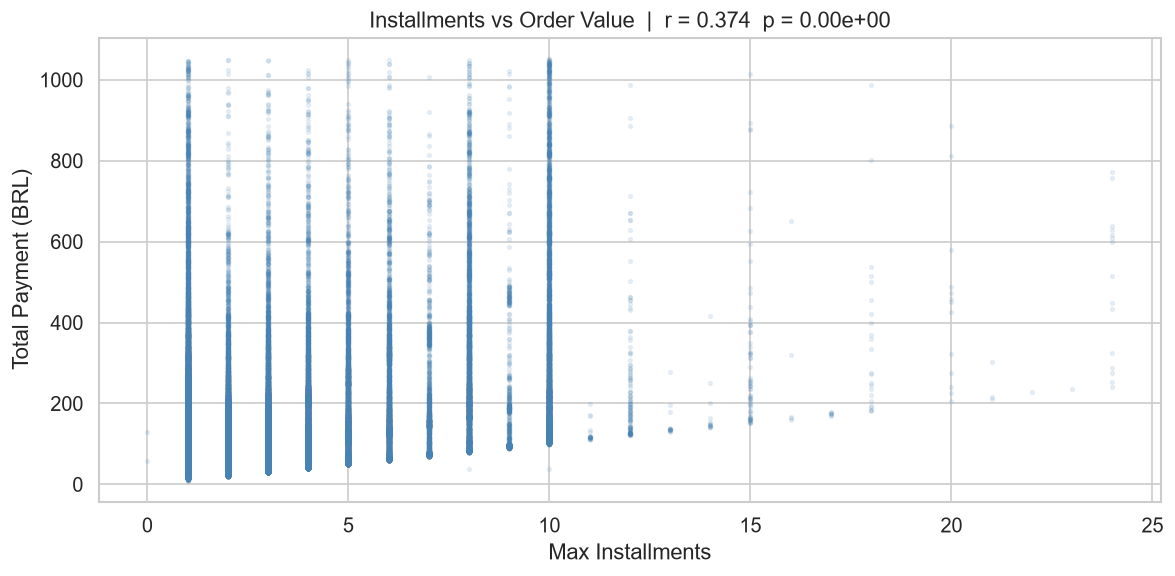

In [14]:
# H3: Payment installments correlate with order value

corr_df = df_delivered.dropna(subset=['max_installments', 'total_payment'])
corr_df = corr_df[corr_df['total_payment'] < corr_df['total_payment'].quantile(0.99)]

r, p = stats.pearsonr(corr_df['max_installments'], corr_df['total_payment'])

print('H3: Installments vs Order Value (Pearson correlation)')
print(f'  Pearson r: {r:.4f}')
print(f'  p-value:   {p:.4e}')
print(f'  Result: {"REJECT H0" if p < alpha else "FAIL TO REJECT H0"} (alpha={alpha})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(corr_df['max_installments'], corr_df['total_payment'], alpha=0.1, s=5, color='steelblue')
ax.set_xlabel('Max Installments')
ax.set_ylabel('Total Payment (BRL)')
ax.set_title(f'Installments vs Order Value  |  r = {r:.3f}  p = {p:.2e}')
plt.tight_layout()
plt.show()

### 4.2 Results - H3 (installments vs. order value)

- **Pearson r = 0.3740**, **p-value â‰ˆ 0** -> **REJECT H0**.
- The correlation is positive and statistically significant, but only **moderate** in
  magnitude (r â‰ˆ 0.37): higher installment plans are associated with higher order values,
  but installments alone explain only a fraction of the variance in order value (rÂ² â‰ˆ 0.14)
  - other factors (product category, freight, customer profile) also matter.

### 4.3 H4 - Review scores across product categories (one-way ANOVA)

H4: Review scores across product categories (ANOVA)
  F-statistic: 32.5414
  p-value:     1.1291e-57
  Result: REJECT H0 (alpha=0.05)


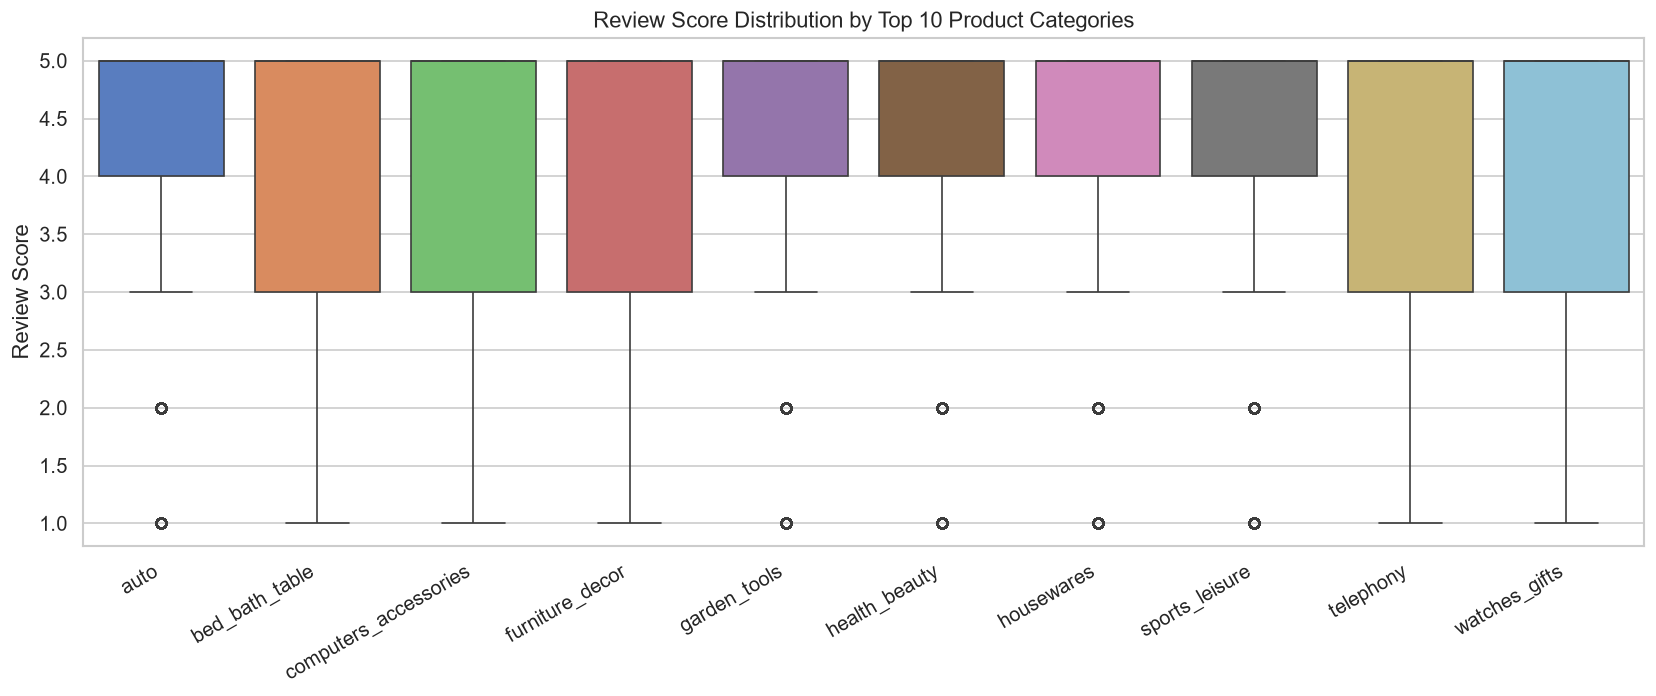

In [15]:
# H4: Review scores differ across product categories (ANOVA)

cat_df = (
    order_items[['order_id', 'product_id']]
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(product_names, on='product_category_name', how='left')
    .merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='left')
    .dropna(subset=['product_category_name_english', 'review_score'])
)

top_cats = cat_df['product_category_name_english'].value_counts().head(10).index
cat_filtered = cat_df[cat_df['product_category_name_english'].isin(top_cats)]

groups = [g['review_score'].values for _, g in cat_filtered.groupby('product_category_name_english')]
f_stat, p_val_anova = stats.f_oneway(*groups)

print('H4: Review scores across product categories (ANOVA)')
print(f'  F-statistic: {f_stat:.4f}')
print(f'  p-value:     {p_val_anova:.4e}')
print(f'  Result: {"REJECT H0" if p_val_anova < alpha else "FAIL TO REJECT H0"} (alpha={alpha})')

fig, ax = plt.subplots(figsize=(14, 6))
order = cat_filtered.groupby('product_category_name_english')['review_score'].median().sort_values().index
sns.boxplot(data=cat_filtered, x='product_category_name_english', y='review_score',
            order=order, palette='muted', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Review Score Distribution by Top 10 Product Categories')
ax.set_xlabel('')
ax.set_ylabel('Review Score')
plt.tight_layout()
plt.show()

### 4.3 Results - H4 (review scores across categories)

- **F-statistic = 32.54**, **p-value = 1.13e-57** -> **REJECT H0**: review scores differ
  significantly across the top 10 product categories by order volume.
- Visually, most categories cluster around a median review score of 4-5, but spread
  differs: **telephony** and **watches_gifts** show the widest dispersion toward lower
  scores, while **auto**, **computers_accessories** and **furniture_decor** cluster tighter
  near the top of the scale - consistent with category-specific satisfaction drivers (e.g.
  product fragility/expectations) beyond delivery performance alone.

## 5. Key Insights & Business Storytelling

> *"Data that don't change a decision or a belief aren't worth collecting."*
> Provost & Fawcett, *Data Science for Business*

### 5.1 Insight - Late delivery is a satisfaction killer (H1)

**Finding:** Late orders average a 2.27 review score versus 4.29 for on-time/early orders -
a statistically significant (p â‰ˆ 0) and practically huge difference (Cohen's d = 1.47).
**Business implication:** Delivery reliability is likely the single largest controllable
driver of customer satisfaction in this dataset, well beyond product or category effects.
**Recommended action:** Prioritize carrier SLA monitoring and proactively communicate
realistic delivery windows; since estimates are already conservative on average (median
~10 days early), the 6.8% of orders that do run late deserve focused operational attention
(e.g. carrier scorecards, regional delay alerts).

### 5.2 Insight - Southeast dominates, but at what cost? (H2)

**Finding:** The Southeast region (SP, RJ, MG, ES) generates 64.6% of revenue, confirming
H2. However, RJ - the second-largest state by revenue - has an average review score below
the 4.0 benchmark, unlike SP and MG.
**Business implication:** Revenue concentration in the Southeast does not automatically
translate into satisfaction concentration; RJ represents a high-value market with an
underlying service gap.
**Recommended action:** Investigate RJ-specific logistics (carrier performance, last-mile
delivery times) given its outsized revenue contribution relative to its review performance.

### 5.3 Insight - Installment plans unlock higher tickets (H3)

**Finding:** Installments correlate positively with order value (r = 0.374, p â‰ˆ 0), but the
relationship is moderate, not strong - installments alone explain roughly 14% of the
variance in order value.
**Business implication:** Offering more installment options can support higher-ticket
purchases, but it is one lever among several (category, freight, customer segment) and
should not be over-relied upon in isolation.
**Recommended action:** Test expanding installment limits specifically for higher-ticket
categories rather than marketplace-wide, and measure the incremental lift versus other
levers (e.g. free shipping thresholds).

### 5.4 Insight - Not all categories are equal in satisfaction (H4)

**Finding:** Review scores differ significantly across the top 10 product categories
(ANOVA F = 32.54, p = 1.13e-57). Telephony and watches_gifts show the widest spread toward
low scores, while auto, computers_accessories and furniture_decor cluster near the top.
**Business implication:** Category-level satisfaction drivers exist independently of
delivery performance - likely tied to product expectations, fragility, or accuracy of
listings.
**Recommended action:** Prioritize seller quality audits and listing-accuracy reviews for
the lowest-scoring categories (telephony, watches_gifts) before scaling marketing spend on
them.

---
## 6. Conclusions and Next Steps

### 6.1 General conclusion

All four hypotheses were addressed and three were formally tested with strong statistical
support:

- **H1 (confirmed):** Late delivery is associated with a dramatic drop in review scores
  (4.29 -> 2.27, Cohen's d = 1.47) - the single most impactful factor identified.
- **H2 (confirmed):** The Southeast region accounts for 64.6% of revenue, but revenue
  concentration and satisfaction are not aligned within the region (RJ underperforms on
  reviews despite high revenue).
- **H3 (confirmed, moderate effect):** Installments correlate positively with order value
  (r = 0.374), but explain only a modest share of the variance.
- **H4 (confirmed):** Review scores differ significantly across product categories,
  pointing to category-specific satisfaction drivers beyond delivery.

**Business takeaway:** Delivery reliability is the dominant lever for customer satisfaction
in this dataset; geographic and category-level effects are secondary but still actionable.

### 6.2 Limitations

- **Sampling:** the dataset covers 2016-2018 and may not reflect current behavior. A
  time-windowed analysis would be more reliable for current decision-making.
- **Causality:** correlation is not causation. Late deliveries correlating with low scores
  doesn't prove delay caused the score - customer expectations and product quality are
  plausible confounders.
- **Multiple testing:** running three formal hypothesis tests increases Type I error risk.
  A Bonferroni correction (alpha / 3 â‰ˆ 0.0167) would be appropriate in a stricter setting,
  though all three p-values here are orders of magnitude below that threshold.

### 6.3 Connection to Project 03

The variables explored here (delivery delay, review score, payment installments, customer
state) become natural **features** for a churn or satisfaction prediction model in
`03_ml_supervised_pipeline/`.